# Exercise 4

## Import packages

In [14]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR

## Task 1
(3 points)

Implement the training loop for one training epoch.
An epoch trains on the whole training dataset once.

In [15]:
def train(model, use_cuda, train_loader, optimizer, epoch, log_interval):
    """
    Train one epoch
    
    model -- the neural network
    use_cuda -- true if GPU should be used
    train_loader -- data loader
    optimizer -- network optimizer
    epoch -- number of current epoch
    log_interval -- number of training steps between logs
    """
    device = torch.device("cuda" if use_cuda and torch.cuda.is_available() else "cpu")
    model.to(device)

    # set the model to train mode
    model.train()
    
    #       enumerate over the dataloader to get mini batches
    #       of images and ground truth labels
    # HINT: the builtin python function enumerate() also gives you indices
    for batch_idx, (data, target) in enumerate(train_loader):
        # move data and labels to device
        data, target = data.to(device), target.to(device)
        
        # set the optimizers gradients to zero
        optimizer.zero_grad()
        
        
        # run the network
        output = model(data)
        
        
        # compute negative log likelihood loss
        loss = F.nll_loss(output, target) 
        
        # do backpropagation
        loss.backward()
        
        # optimize
        optimizer.step()
       
        
        # print current loss for every nth ("log_interval"th) iteration
        if batch_idx % log_interval == 0:
            print(f'Train Epoch: {epoch} '
                  f'[{batch_idx * len(data)}/{len(train_loader.dataset)} '
                  f'({100. * batch_idx / len(train_loader):.0f}%)]\t'
                  f'Loss: {loss.item():.6f}')
        

We already implemented the validation function for you (this is essentially validate() from the last exercise)

In [16]:
def validate(model, use_cuda, test_loader):
    """
    Compute test metrics
    
    model -- the neural network
    use_cuda -- true if GPU should be used
    test_loader -- data loader
    """
    # create a 10x10 grid of subplots
    _, axis = plt.subplots(10, 10)
    
    # set model to evaluation mode
    model.eval()
    test_loss = 0
    correct = 0
    plotted = 0
    
    # disable gradients globally
    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(test_loader):
            # for each batch
            if use_cuda:
                # transfer to GPU
                data = data.cuda()
                target = target.cuda()
            
            # run network and compute metrics
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()  # sum up batch loss
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            
            img_correct = pred.eq(target.view_as(pred))
            correct += pred.eq(target.view_as(pred)).sum().item()
            
            # plot the first 100 images
            img_idx = 0
            data = data.cpu().numpy()
            
            while plotted < 100 and img_idx < data.shape[0]:
                # compute position of ith image in the grid
                y = plotted % 10
                x = plotted // 10
                
                # convert image tensor to numpy array and normalize to [0, 1]
                img = data[img_idx, 0]
                img = (img - np.min(img)) / (np.max(img) - np.min(img))
                
                # make wrongly predicted images red
                img = np.stack([img] * 3, 2)
                if img_correct[img_idx] == 0:
                    img[:, :, 1:] = 0.0
                
                # disable axis and show image
                axis[y][x].axis('off')
                axis[y][x].imshow(img)
                
                # show the predicted class next to each image
                axis[y][x].text(30, 25, pred[img_idx].item())
                
                plotted += 1
                img_idx += 1
            
    test_loss /= len(test_loader.dataset)

    # show results
    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))
    plt.show()

## Task 2
(4 points)

Implement a five-layer fully connected neural network.
The dimensions (without batch size) should change like this: 784->200->100->60->30->10
Use log softmax to compute the class predictions.

Run the code at the end of the notebook to train and validate your implementation.

### Task 2.1
* sigmoid non-linear activation function
* note that the last layer does not need an activation function!

### Task 2.2
* add a new class "FCNet2"
* replace sigmoid with ReLU

### Task 2.3
* add a new class "FCNet2"
* add batch normalization to the first and third layers (note the difference between 1D/2D/3D versions)


**NOTE:** The perfomance should improve slightly with each step. However, due to the random weight initialization applied by PyTorch, your results may vary a bit between trainings.

In [17]:
class FCNet1(nn.Module):
    """
    Fully Connected Neural Network
    
    Five fully connected layers with sigmoid non-linearity
    
    Dimensions
    784->200->100->60->30->10
    """
    def __init__(self):
        super(FCNet1, self).__init__()
        
        # TODO: initialize network layers
        # HINT: take a look at "torch.nn" (imported as "nn")
        self.layer1 = nn.Linear(784, 200)
        self.layer2 = nn.Linear(200, 100)
        self.layer3 = nn.Linear(100, 60)
        self.layer4 = nn.Linear(60, 30)
        self.layer5 = nn.Linear(30, 10)
       

    def forward(self, x):
        # reshape batch of images to batch of 1D vectors
        x = x.view(x.size(0), -1) 

        
        # run network layers
        x = self.layer1(x)
        x = torch.sigmoid(x)
        x = self.layer2(x)
        x = torch.sigmoid(x)
        x = self.layer3(x)
        x = torch.sigmoid(x)
        x = self.layer4(x)
        x = torch.sigmoid(x)
        x = self.layer5(x)

        
        
        # compute log softmax over the output
        # HINT: take a look at "torch.nn.functional" (imported as "F")
        output = F.log_softmax(x, dim=1)
        
        
        return output

In [18]:
class FCNet2(nn.Module):
    def __init__(self):
        super(FCNet2, self).__init__()
        self.layer1 = nn.Linear(784, 200)
        self.layer2 = nn.Linear(200, 100)
        self.layer3 = nn.Linear(100, 60)
        self.layer4 = nn.Linear(60, 30)
        self.layer5 = nn.Linear(30, 10)

    def forward(self, x):
        # reshape batch of images to batch of 1D vectors
        x = x.view(x.size(0), -1) 

        
        # run network layers
        x = self.layer1(x)
        x = torch.relu(x)
        x = self.layer2(x)
        x = torch.relu(x)
        x = self.layer3(x)
        x = torch.relu(x)
        x = self.layer4(x)
        x = torch.relu(x)
        x = self.layer5(x)

        output = F.log_softmax(x, dim=1)
        
        return output

In [19]:
class FCNet3(nn.Module):
    def __init__(self):
        super(FCNet3, self).__init__()
        
        # fully connected layers
        self.fc1 = nn.Linear(28 * 28, 200)
        self.bn1 = nn.BatchNorm1d(200)
        self.fc2 = nn.Linear(200, 100)
        self.fc3 = nn.Linear(100, 60)
        self.bn3 = nn.BatchNorm1d(60)
        self.fc4 = nn.Linear(60, 30)
        self.fc5 = nn.Linear(30, 10)
        
    def forward(self, x):
        # reshape input
        x = x.view(x.size(0), -1)

        # run network with batchnorm on first and third layers
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.fc2(x))
        x = F.relu(self.bn3(self.fc3(x)))
        x = F.relu(self.fc4(x))
        x = self.fc5(x)

        return F.log_softmax(x, dim=1)

## Task 3
(3 points)

Implement a convolutional neural network, consisting of two convolutional and two fully connected layers.
This time, the dimensions (without batch size) should change like this: 1x28x28->32x26x26->64x12x12->128->10

### Task 3.1
* two convolutional layers (kernel size 3)
* two fully-connected layers
* ReLU activation function

### Task 3.2
* add batch normalization to first convolutional and first fully connected layer

### Task 3.3
* use max pooling instead of stride to reduce the dimensions to 64x12x12

In [20]:
class ConvNet1(nn.Module):
    """
    Convolutional Neural Network
    
    Two convolutional layers and two fully connected layers
    
    Dimensions:
    1x28x28->32x26x26->64x12x12->128->10
    """
    def __init__(self):
        super(ConvNet1, self).__init__()
        
        # initialize network layers
        self.conv1 = nn.Conv2d(in_channels= 1, out_channels=32, kernel_size=3)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2)
        self.fc1 = nn.Linear(64 * 12 * 12, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # run convolutional layers
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.conv2(x)
        x = torch.relu(x)

              
        
        # reshape batch of images to batch of 1D vectors
        x = x.view(x.size(0), -1)
        
        
        # run fully connected layers
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)
        
        # compute log softmax over the output
        output = F.log_softmax(x, dim=1)
        
        
        return output

In [21]:
class ConvNet2(nn.Module):
    def __init__(self):
        super(ConvNet2, self).__init__()

        self.conv1 = nn.Conv2d(in_channels= 1, out_channels=32, kernel_size=3)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2)
        self.fc1 = nn.Linear(64 * 12 * 12, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 10)


    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.conv2(x)
        x = torch.relu(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.bn2(x)
        x = torch.relu(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output

In [22]:
class ConvNet3(nn.Module):
    def __init__(self):
        super(ConvNet3, self).__init__()

        self.conv1 = nn.Conv2d(in_channels= 1, out_channels=32, kernel_size=3)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1)
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 12 * 12, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 10)


    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = torch.relu(x)

        x = self.conv2(x)
        x = torch.relu(x)
        x = self.maxpool(x)

        x = x.view(x.size(0), -1)
        
        x = self.fc1(x)
        x = self.bn2(x)
        x = torch.relu(x)

        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output

Training model: FCNet1
Train Epoch: 1 [0/60000 (0%)]	Loss: 2.280504
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.309147
Train Epoch: 1 [12800/60000 (21%)]	Loss: 2.276276
Train Epoch: 1 [19200/60000 (32%)]	Loss: 2.301578
Train Epoch: 1 [25600/60000 (43%)]	Loss: 2.313859
Train Epoch: 1 [32000/60000 (53%)]	Loss: 2.298533
Train Epoch: 1 [38400/60000 (64%)]	Loss: 2.179959
Train Epoch: 1 [44800/60000 (75%)]	Loss: 1.794544
Train Epoch: 1 [51200/60000 (85%)]	Loss: 1.703679
Train Epoch: 1 [57600/60000 (96%)]	Loss: 1.686614

Test set: Average loss: 1.7264, Accuracy: 2575/10000 (25.75%)



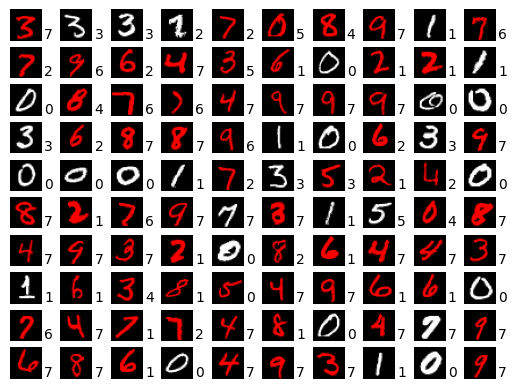

Train Epoch: 2 [0/60000 (0%)]	Loss: 1.727888
Train Epoch: 2 [6400/60000 (11%)]	Loss: 1.295395
Train Epoch: 2 [12800/60000 (21%)]	Loss: 1.289421
Train Epoch: 2 [19200/60000 (32%)]	Loss: 1.078263
Train Epoch: 2 [25600/60000 (43%)]	Loss: 1.009129
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.970664
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.702759
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.552167
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.582160
Train Epoch: 2 [57600/60000 (96%)]	Loss: 0.578903

Test set: Average loss: 0.5301, Accuracy: 8876/10000 (88.76%)



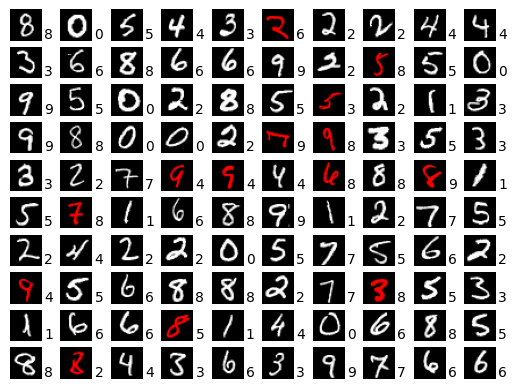

Train Epoch: 3 [0/60000 (0%)]	Loss: 0.511679
Train Epoch: 3 [6400/60000 (11%)]	Loss: 0.651739
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.306842
Train Epoch: 3 [19200/60000 (32%)]	Loss: 0.321446
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.556628
Train Epoch: 3 [32000/60000 (53%)]	Loss: 0.259182
Train Epoch: 3 [38400/60000 (64%)]	Loss: 0.392945
Train Epoch: 3 [44800/60000 (75%)]	Loss: 0.282150
Train Epoch: 3 [51200/60000 (85%)]	Loss: 0.265857
Train Epoch: 3 [57600/60000 (96%)]	Loss: 0.341446

Test set: Average loss: 0.3480, Accuracy: 9179/10000 (91.79%)



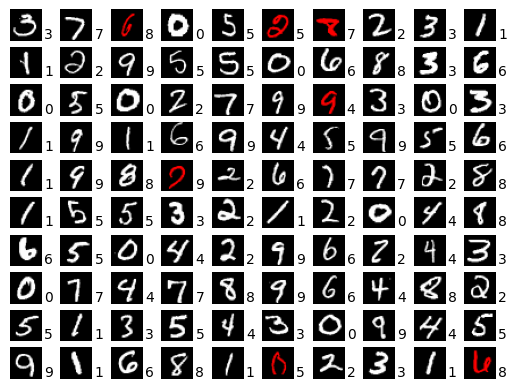

Finished training model: FCNet1













Training model: FCNet2
Train Epoch: 1 [0/60000 (0%)]	Loss: 2.334778
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.439432
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.155276
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.442075
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.290339
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.252338
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.248363
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.146157
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.078383
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.121698

Test set: Average loss: 0.1622, Accuracy: 9517/10000 (95.17%)



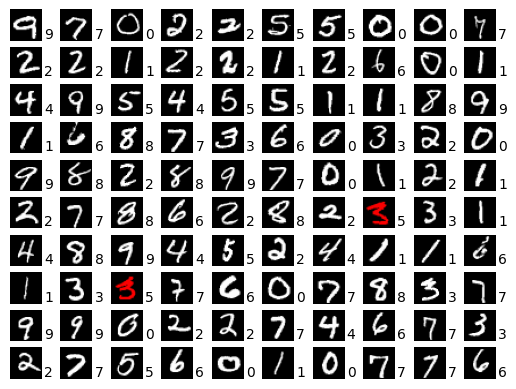

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.043202
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.061250
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.217817
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.042332
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.109111
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.132837
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.057622
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.017889
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.154881
Train Epoch: 2 [57600/60000 (96%)]	Loss: 0.056086

Test set: Average loss: 0.0996, Accuracy: 9710/10000 (97.10%)



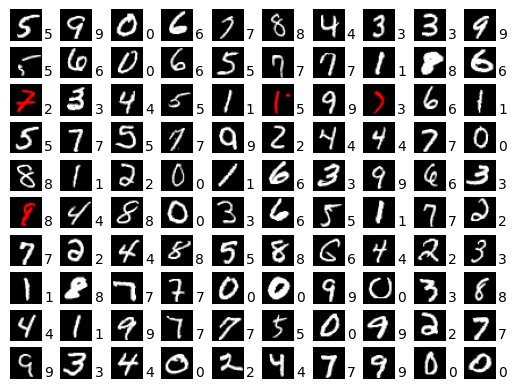

Train Epoch: 3 [0/60000 (0%)]	Loss: 0.010363
Train Epoch: 3 [6400/60000 (11%)]	Loss: 0.076376
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.054200
Train Epoch: 3 [19200/60000 (32%)]	Loss: 0.085082
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.016884
Train Epoch: 3 [32000/60000 (53%)]	Loss: 0.047449
Train Epoch: 3 [38400/60000 (64%)]	Loss: 0.002348
Train Epoch: 3 [44800/60000 (75%)]	Loss: 0.017506
Train Epoch: 3 [51200/60000 (85%)]	Loss: 0.105570
Train Epoch: 3 [57600/60000 (96%)]	Loss: 0.024371

Test set: Average loss: 0.0805, Accuracy: 9793/10000 (97.93%)



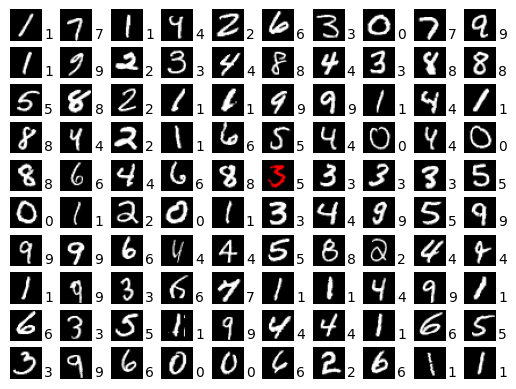

Finished training model: FCNet2













Training model: FCNet3
Train Epoch: 1 [0/60000 (0%)]	Loss: 2.314336
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.322541
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.219379
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.342074
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.150402
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.072799
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.306073
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.211192
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.091666
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.118792

Test set: Average loss: 0.0987, Accuracy: 9703/10000 (97.03%)



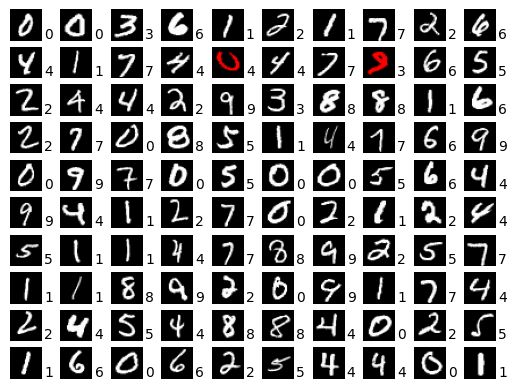

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.043168
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.052633
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.034236
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.137429
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.076336
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.040120
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.060341
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.043323
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.030700
Train Epoch: 2 [57600/60000 (96%)]	Loss: 0.106375

Test set: Average loss: 0.0768, Accuracy: 9765/10000 (97.65%)



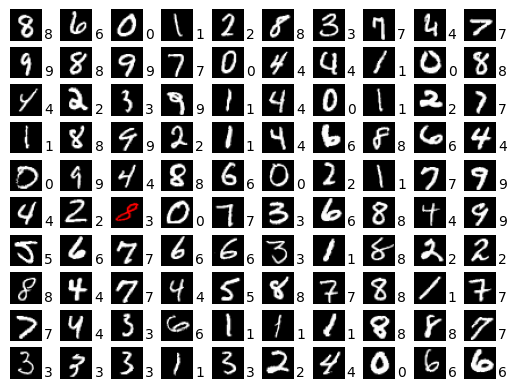

Train Epoch: 3 [0/60000 (0%)]	Loss: 0.097670
Train Epoch: 3 [6400/60000 (11%)]	Loss: 0.004154
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.012468
Train Epoch: 3 [19200/60000 (32%)]	Loss: 0.048775
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.070247
Train Epoch: 3 [32000/60000 (53%)]	Loss: 0.157901
Train Epoch: 3 [38400/60000 (64%)]	Loss: 0.187414
Train Epoch: 3 [44800/60000 (75%)]	Loss: 0.015618
Train Epoch: 3 [51200/60000 (85%)]	Loss: 0.009550
Train Epoch: 3 [57600/60000 (96%)]	Loss: 0.140250

Test set: Average loss: 0.0626, Accuracy: 9791/10000 (97.91%)



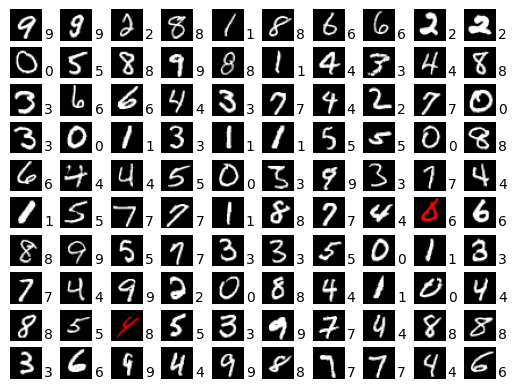

Finished training model: FCNet3













Training model: ConvNet1
Train Epoch: 1 [0/60000 (0%)]	Loss: 2.304057
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.086500
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.333041
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.035091
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.012807
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.024637
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.114210
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.008291
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.097982
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.028775

Test set: Average loss: 0.0371, Accuracy: 9873/10000 (98.73%)



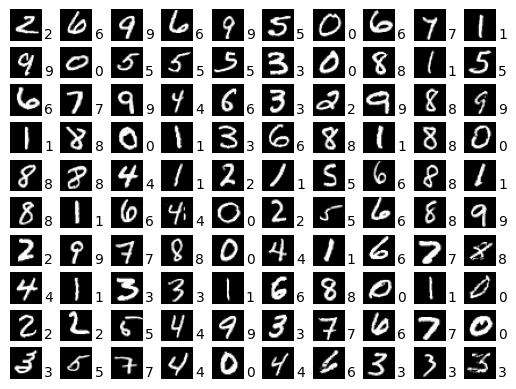

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.005600
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.012806
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.013342
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.012317
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.004525
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.005693
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.041231
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.001765
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.042493
Train Epoch: 2 [57600/60000 (96%)]	Loss: 0.065216

Test set: Average loss: 0.0344, Accuracy: 9879/10000 (98.79%)



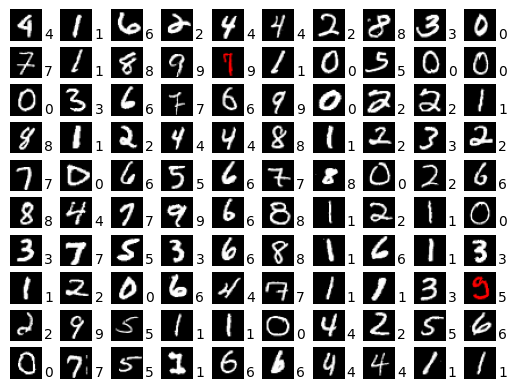

Train Epoch: 3 [0/60000 (0%)]	Loss: 0.010589
Train Epoch: 3 [6400/60000 (11%)]	Loss: 0.000794
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.036209
Train Epoch: 3 [19200/60000 (32%)]	Loss: 0.009737
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.039822
Train Epoch: 3 [32000/60000 (53%)]	Loss: 0.016636
Train Epoch: 3 [38400/60000 (64%)]	Loss: 0.000412
Train Epoch: 3 [44800/60000 (75%)]	Loss: 0.001716
Train Epoch: 3 [51200/60000 (85%)]	Loss: 0.000283
Train Epoch: 3 [57600/60000 (96%)]	Loss: 0.027512

Test set: Average loss: 0.0306, Accuracy: 9907/10000 (99.07%)



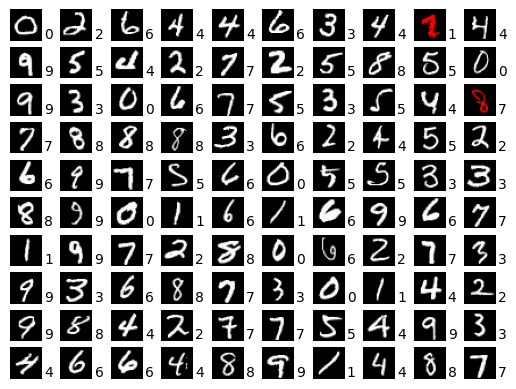

Finished training model: ConvNet1













Training model: ConvNet2
Train Epoch: 1 [0/60000 (0%)]	Loss: 2.370159
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.077277
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.103829
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.005728
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.065360
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.058060
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.174461
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.064234
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.093336
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.019313

Test set: Average loss: 0.0361, Accuracy: 9880/10000 (98.80%)



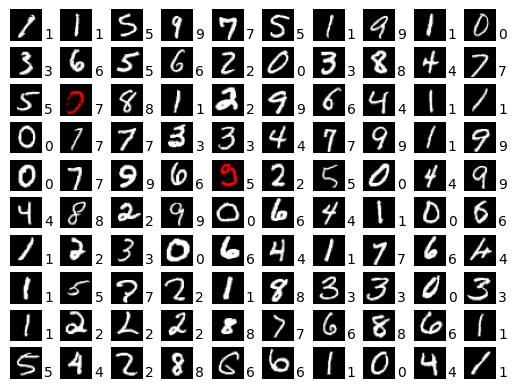

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.059157
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.008245
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.019762
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.020712
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.004579
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.089953
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.011168
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.014573
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.007330
Train Epoch: 2 [57600/60000 (96%)]	Loss: 0.020370

Test set: Average loss: 0.0285, Accuracy: 9905/10000 (99.05%)



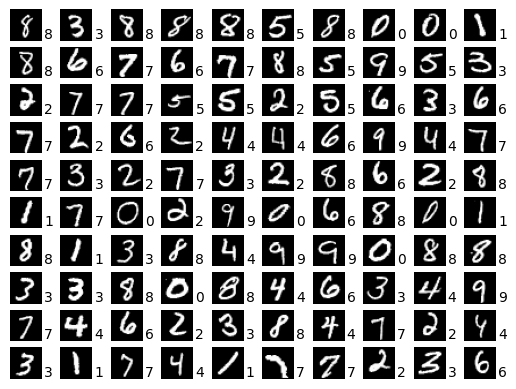

Train Epoch: 3 [0/60000 (0%)]	Loss: 0.010052
Train Epoch: 3 [6400/60000 (11%)]	Loss: 0.005621
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.079422
Train Epoch: 3 [19200/60000 (32%)]	Loss: 0.006438
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.007675
Train Epoch: 3 [32000/60000 (53%)]	Loss: 0.000771
Train Epoch: 3 [38400/60000 (64%)]	Loss: 0.001115
Train Epoch: 3 [44800/60000 (75%)]	Loss: 0.003001
Train Epoch: 3 [51200/60000 (85%)]	Loss: 0.015027
Train Epoch: 3 [57600/60000 (96%)]	Loss: 0.007946

Test set: Average loss: 0.0258, Accuracy: 9903/10000 (99.03%)



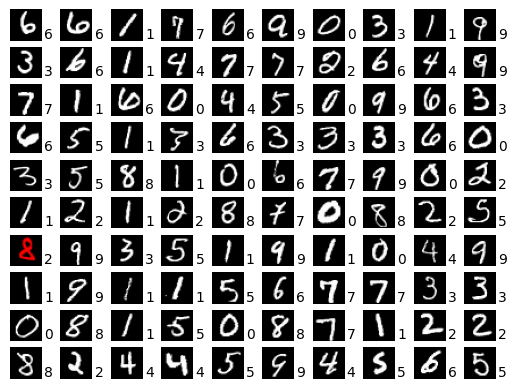

Finished training model: ConvNet2













Training model: ConvNet3
Train Epoch: 1 [0/60000 (0%)]	Loss: 2.342767
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.117784
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.039979
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.018511
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.069705
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.145043
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.041257
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.057721
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.114779
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.015356

Test set: Average loss: 0.0405, Accuracy: 9871/10000 (98.71%)



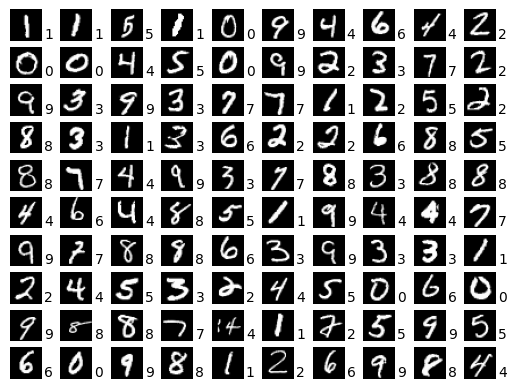

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.040083
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.025385
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.009523
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.036966
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.015975
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.025562
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.005685
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.014644
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.014065
Train Epoch: 2 [57600/60000 (96%)]	Loss: 0.002594

Test set: Average loss: 0.0306, Accuracy: 9903/10000 (99.03%)



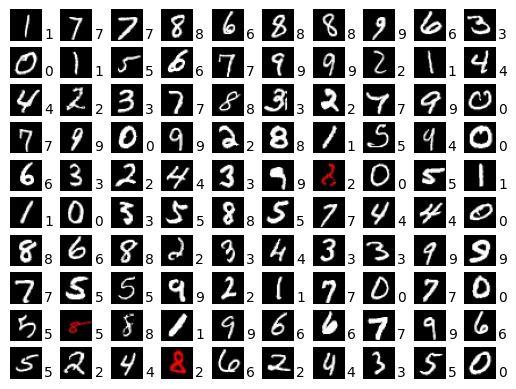

Train Epoch: 3 [0/60000 (0%)]	Loss: 0.023451
Train Epoch: 3 [6400/60000 (11%)]	Loss: 0.034889
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.041570
Train Epoch: 3 [19200/60000 (32%)]	Loss: 0.003175
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.031363
Train Epoch: 3 [32000/60000 (53%)]	Loss: 0.023903
Train Epoch: 3 [38400/60000 (64%)]	Loss: 0.007758
Train Epoch: 3 [44800/60000 (75%)]	Loss: 0.007198
Train Epoch: 3 [51200/60000 (85%)]	Loss: 0.002266
Train Epoch: 3 [57600/60000 (96%)]	Loss: 0.011632

Test set: Average loss: 0.0246, Accuracy: 9918/10000 (99.18%)



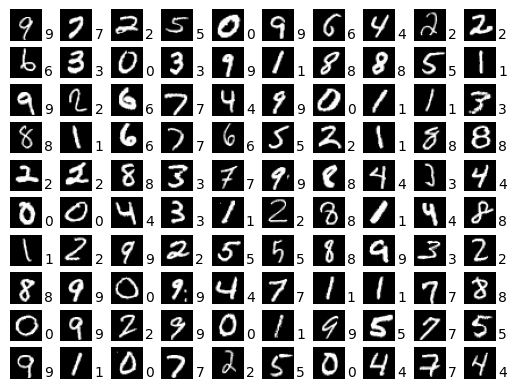

Finished training model: ConvNet3















In [26]:
# hyper parameters
batch_size = 64
test_batch_size = 1000
epochs = 3
lr = 1.0
gamma = 0.7
log_interval = 100

# use GPU if available
use_cuda = torch.cuda.is_available()
kwargs = {'num_workers': 1, 'pin_memory': True} if use_cuda else {}

# initialize data loaders
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=True, download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])), batch_size=batch_size, shuffle=True, **kwargs)

test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=False, 
    transform=transforms.Compose([
        transforms.ToTensor(), 
        transforms.Normalize((0.1307,), (0.3081,))
    ])),
    batch_size=test_batch_size, shuffle=True, **kwargs)



for model,name in [[FCNet1(), "FCNet1"], [FCNet2(), "FCNet2"], [FCNet3(), "FCNet3"], [ConvNet1(), "ConvNet1"], [ConvNet2(), "ConvNet2"], [ConvNet3(), "ConvNet3"]]:
    print(f"Training model: {name}")

    if use_cuda:
        model = model.cuda()

    # initialize optimizer and scheduler
    optimizer = optim.Adadelta(model.parameters(), lr=lr)
    scheduler = StepLR(optimizer, step_size=1, gamma=gamma)

    for epoch in range(1, epochs + 1):
        # train one epoch
        train(model, use_cuda, train_loader, optimizer, epoch, log_interval)
        
        # run on test dataset
        validate(model, use_cuda, test_loader)
        scheduler.step()
        
        
        torch.save(model.state_dict(), "models/mnist/checkpoint.pt")
    print(f"Finished training model: {name}\n\n")
    print("\n"*10)